In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Shape: (418, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


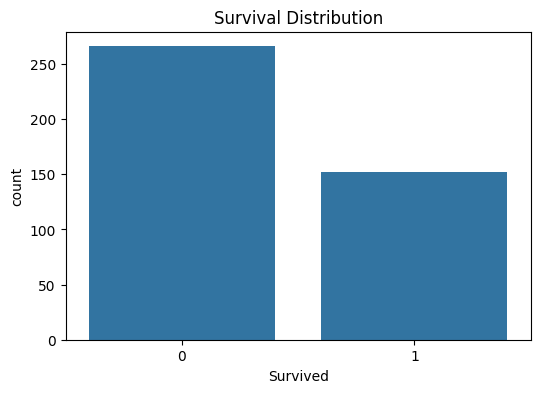

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Survived'
)

plt.title("Survival Distribution")
plt.show()

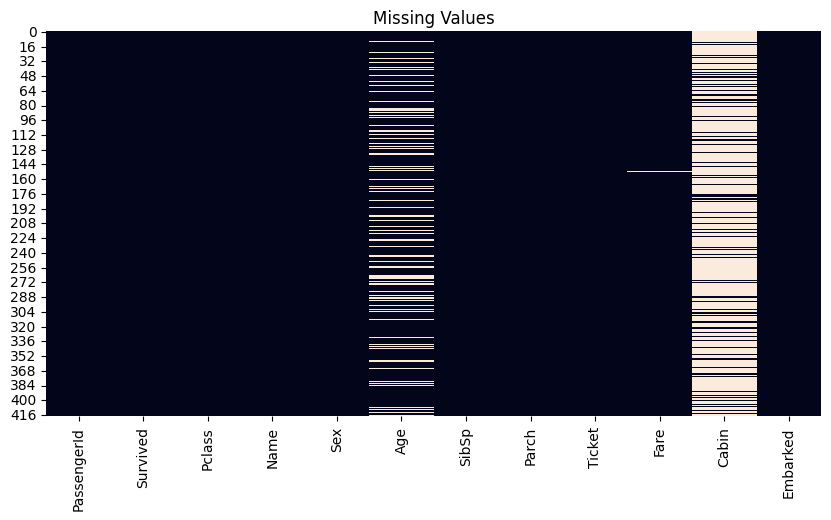

In [5]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

In [6]:
df["Title"] = df["Name"].str.extract(
    r' ([A-Za-z]+)\.',
    expand=False
)

df["Title"].value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


In [7]:
rare_titles = [
    'Lady','Countess','Capt','Col',
    'Don','Dr','Major','Rev',
    'Sir','Jonkheer','Dona'
]

df["Title"] = df["Title"].replace(
    rare_titles,
    "Rare"
)

df["Title"] = df["Title"].replace({
    "Mlle":"Miss",
    "Ms":"Miss",
    "Mme":"Mrs"
})

In [8]:
df["FamilySize"] = (
    df["SibSp"] +
    df["Parch"] +
    1
)

In [9]:
df["CabinPresent"] = np.where(
    df["Cabin"].isnull(),
    0,
    1
)

In [10]:
df["Age"].fillna(
    df["Age"].median(),
    inplace=True
)

In [11]:
df["Embarked"].fillna(
    df["Embarked"].mode()[0],
    inplace=True
)

In [12]:
df["Fare"].fillna(
    df["Fare"].median(),
    inplace=True
)

In [13]:
df.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ],
    inplace=True
)

In [14]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [15]:
numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print(numeric_features)
print(categorical_features)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'CabinPresent'],
      dtype='object')
Index(['Sex', 'Embarked', 'Title'], dtype='object')


In [16]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
models = {

    "Logistic Regression":
    Pipeline([
        ("preprocessor", preprocessor),
        ("model",
         LogisticRegression(max_iter=1000))
    ]),

    "Random Forest":
    Pipeline([
        ("preprocessor", preprocessor),
        ("model",
         RandomForestClassifier(
             n_estimators=200,
             random_state=42
         ))
    ]),

    "Gradient Boosting":
    Pipeline([
        ("preprocessor", preprocessor),
        ("model",
         GradientBoostingClassifier(
             random_state=42
         ))
    ])
}

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



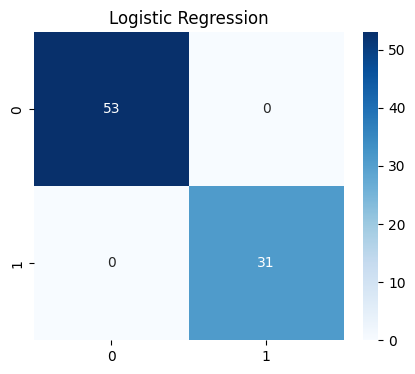

Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



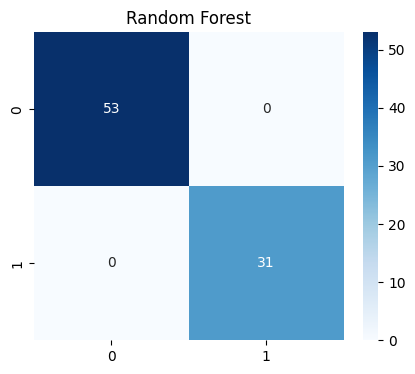

Gradient Boosting
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



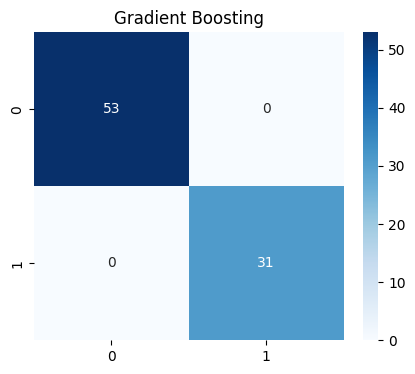

In [19]:
results = []

best_model = None
best_accuracy = 0

for name, model in models.items():

    print("="*60)
    print(name)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print(
        classification_report(
            y_test,
            predictions
        )
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(name)
    plt.show()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name

In [20]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0


In [21]:
rf_model = models["Random Forest"]

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'CabinPresent'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Sex', 'Embarked', 'Title'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [22]:
feature_names = (
    numeric_features.tolist()
    +
    list(
        rf_model.named_steps[
            "preprocessor"
        ]
        .transformers_[1][1]
        .named_steps["encoder"]
        .get_feature_names_out(
            categorical_features
        )
    )
)

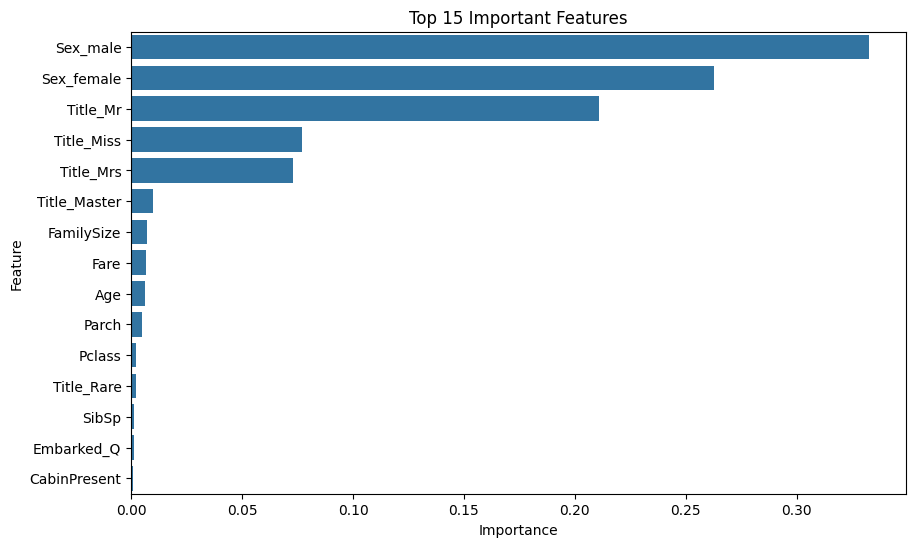

In [23]:
importances = rf_model.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": importances

}).sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

In [24]:
print(
    "Best Model:",
    best_model_name
)

joblib.dump(
    best_model,
    "titanic_survival_model.joblib"
)

print(
    "Model Saved Successfully"
)

Best Model: Logistic Regression
Model Saved Successfully


In [25]:
loaded_model = joblib.load(
    "titanic_survival_model.joblib"
)

In [26]:
sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

print(
    "Predicted Survival:",
    prediction[0]
)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Predicted Survival: 0
Passenger Did Not Survive
